# Worksheet 6

## - 23MS121 
## - Manish Behera

## Van der Pol Oscillator

The Van der Pol oscillator is defined by:

$$\frac{d^2 y}{dx^2} = \mu (1 - y^2) \frac{dy}{dx} - \lambda y$$

To solve numerically, we convert this 2nd-order ODE into a system of two 1st-order ODEs. Let:

$$y_1 = y, \quad y_2 = \frac{dy}{dx}$$

Then:

$$\frac{dy_1}{dx} = y_2$$
$$\frac{dy_2}{dx} = \mu (1 - y_1^2)\, y_2 - \lambda\, y_1$$

**Parameters:** $\mu = 5$, $\lambda = 40$, $t \in [0, 20]$, $y(0) = 0.5$, $y'(0) = 0.0$

In [11]:
import numpy as np
import matplotlib.pyplot as plt

In [12]:
# Basic Runge Kutta 4
def rk4(fn, x, y, h):
    k1 = h*fn(x, y)
    k2 = h*fn(x+h/2, y+k1/2)
    k3 = h*fn(x+h/2, y+k2/2)
    k4 = h*fn(x+h, y+k3)
    return y + (k1+2*k2+2*k3+k4)/6

# RK4 caller function
def caller(my_method, fn, y_ini, x0, xT, h):
    xs = np.arange(x0, xT, h)
    N = len(xs)
    y = y_ini
    ys = np.zeros((N, len(y_ini)))
    for i in range(N):
        ys[i,:] = y
        x = xs[i]
        y = my_method(fn, x, y, h)
    return ys

# ---- Dormand-Prince Butcher Tableau coefficients ----
a2 = 1/5;  b21 = 1/5
a3 = 3/10; b31 = 3/40;       b32 = 9/40
a4 = 4/5;  b41 = 44/45;      b42 = -56/15;      b43 = 32/9
a5 = 8/9;  b51 = 19372/6561; b52 = -25360/2187; b53 = 64448/6561; b54 = -212/729
a6 = 1;    b61 = 9017/3168;  b62 = -355/33;     b63 = 46732/5247; b64 = 49/176;  b65 = -5103/18656
a7 = 1;    b71 = 35/384;     b72 = 0;           b73 = 500/1113;   b74 = 125/192; b75 = -2187/6784;  b76 = 11/84

# 5th-order weights
c1 = 35/384; c2 = 0; c3 = 500/1113; c4 = 125/192; c5 = -2187/6784; c6 = 11/84; c7 = 0
# 4th-order weights (for error estimation)
c1s = 5179/57600; c2s = 0; c3s = 7571/16695; c4s = 393/640; c5s = -92097/339200; c6s = 187/2100; c7s = 1/40

# Embedded RK5(4) with FSAL
def erk54h(f, x, y, h, k7bh):
    if np.sum(np.abs(k7bh)) == 0:
        k1 = h*f(x, y)
    else:
        k1 = k7bh*h

    k2 = h*f(x + a2*h, y + b21*k1)
    k3 = h*f(x + a3*h, y + b31*k1 + b32*k2)
    k4 = h*f(x + a4*h, y + b41*k1 + b42*k2 + b43*k3)
    k5 = h*f(x + a5*h, y + b51*k1 + b52*k2 + b53*k3 + b54*k4)
    k6 = h*f(x + a6*h, y + b61*k1 + b62*k2 + b63*k3 + b64*k4 + b65*k5)

    y5 = y + c1*k1 + c2*k2 + c3*k3 + c4*k4 + c5*k5 + c6*k6
    k7bh = f(x + a7*h, y5)
    y4 = y + c1s*k1 + c2s*k2 + c3s*k3 + c4s*k4 + c5s*k5 + c6s*k6 + c7s*k7bh*h

    err = np.abs(y5 - y4)
    return y5, err, k7bh

# Adaptive caller using Dormand-Prince RK5(4)
def caller54(fn, y_ini, x0, xT, h0, max_iter, abstol, reltol):
    y = np.asarray(y_ini, dtype=float)
    h = h0
    ys = np.zeros((max_iter, len(y_ini)))
    xs = np.zeros((max_iter, 1))
    xs[0] = x0
    ys[0,:] = y
    x = x0
    i = 0
    k7bh = np.zeros(len(y_ini))

    while x <= xT and i < max_iter:
        tol = abstol + reltol*np.linalg.norm(ys[i,:])
        y_new, err, k7bh = erk54h(fn, xs[i], ys[i,:], h, k7bh)
        merr = np.max(err)

        if merr == 0.0:
            merr = tol/100

        hnew = 0.9*h*(tol/merr)**0.2

        if merr < tol and h/5 < hnew < 5*h:
            x += h
            i += 1
            xs[i] = x
            ys[i,:] = y_new

        h = hnew

    if i >= max_iter:
        print(i, " Increase max_iter.")
        return None

    return xs[1:i], ys[1:i,:]

In [13]:
# y1 = y,  y2 = dy/dx
# dy1/dx = y2
# dy2/dx = mu*(1 - y1^2)*y2 - lambda*y1

mu = 5.0
lam = 40.0   # lambda is a reserved keyword in Python

def vdp(x, y):
    y1, y2 = y
    dy1 = y2
    dy2 = mu*(1 - y1**2)*y2 - lam*y1
    return np.array([dy1, dy2])

# Initial conditions
y_ini = np.array([0.5, 0.0])

# Time span
x0 = 0.0
xT = 20.0

## Part (a) — Regular RK4 with $h = 10^{-4}$

Since the Van der Pol oscillator with $\mu = 5$ exhibits sharp transitions, we need a very small fixed step size to capture the dynamics accurately. We use the basic RK4 method with $h = 10^{-4}$, giving $N = 200{,}000$ steps over $[0, 20]$.

In [4]:
# Part (a): RK4 with h = 1e-4
h_rk4 = 1e-4
xs_rk4 = np.arange(x0, xT, h_rk4)
N_rk4 = len(xs_rk4)
print(f"Number of RK4 steps: {N_rk4}")

ys_rk4 = caller(rk4, vdp, y_ini, x0, xT, h_rk4)
print("RK4 computation done.")

Number of RK4 steps: 200000
RK4 computation done.


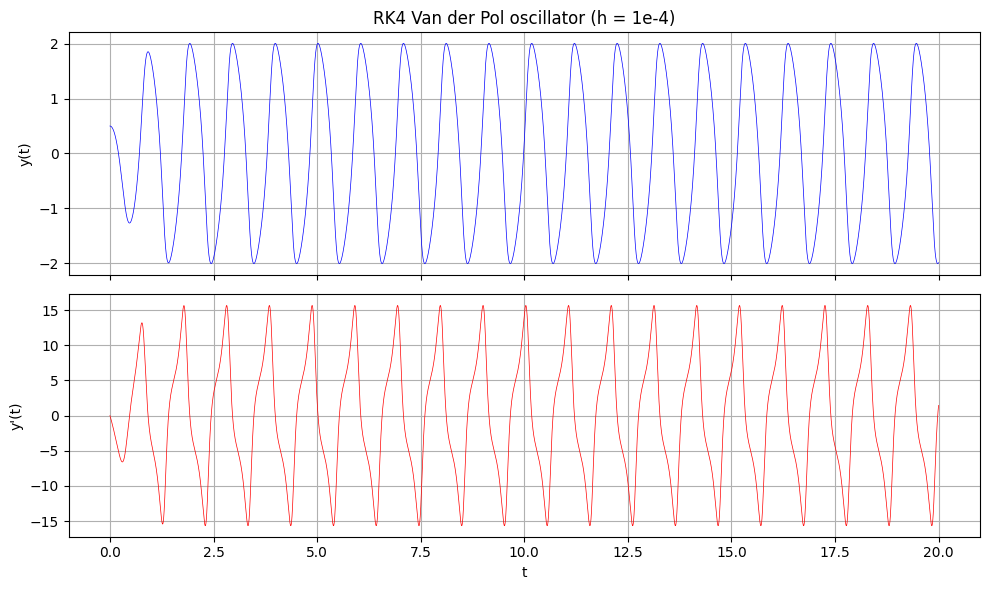

In [14]:
# Plot RK4 solution: y(t) and y'(t)
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(xs_rk4, ys_rk4[:, 0], 'b-', linewidth=0.5)
axes[0].set_ylabel('y(t)')
axes[0].set_title('RK4 Van der Pol oscillator (h = 1e-4)')
axes[0].grid(True)

axes[1].plot(xs_rk4, ys_rk4[:, 1], 'r-', linewidth=0.5)
axes[1].set_ylabel("y'(t)")
axes[1].set_xlabel('t')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Part (b) — Dormand-Prince Adaptive Method

We now solve the same system using the embedded RK5(4) Dormand-Prince method with adaptive time stepping. The method automatically chooses small steps during the sharp transitions and large steps during the slow-varying regions, making it far more efficient than fixed-step RK4.

**Tolerances:** `abstol = 1e-6`, `reltol = 1e-8`

In [6]:
# Part (b): Dormand-Prince adaptive method
max_iter = 50000
abstol = 1.0e-6
reltol = 1.0e-8
h0 = 0.01  # initial step size guess

xs_dp, ys_dp = caller54(vdp, y_ini.tolist(), x0, xT, h0, max_iter, abstol, reltol)

n_steps_dp = len(xs_dp)
print(f"Number of adaptive time steps (Dormand-Prince): {n_steps_dp}")

Number of adaptive time steps (Dormand-Prince): 17136


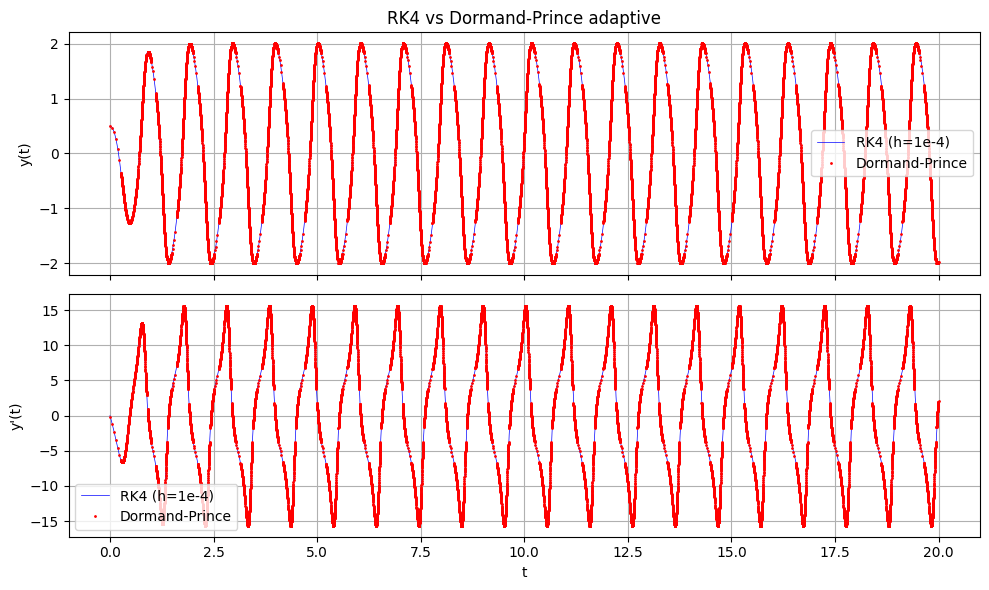

In [15]:
# Plot Dormand-Prince solution and compare with RK4
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(xs_rk4, ys_rk4[:, 0], 'b-', linewidth=0.5, label='RK4 (h=1e-4)')
axes[0].plot(xs_dp, ys_dp[:, 0], 'r.', markersize=2, label='Dormand-Prince')
axes[0].set_ylabel('y(t)')
axes[0].set_title('RK4 vs Dormand-Prince adaptive')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(xs_rk4, ys_rk4[:, 1], 'b-', linewidth=0.5, label='RK4 (h=1e-4)')
axes[1].plot(xs_dp, ys_dp[:, 1], 'r.', markersize=2, label='Dormand-Prince')
axes[1].set_ylabel("y'(t)")
axes[1].set_xlabel('t')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

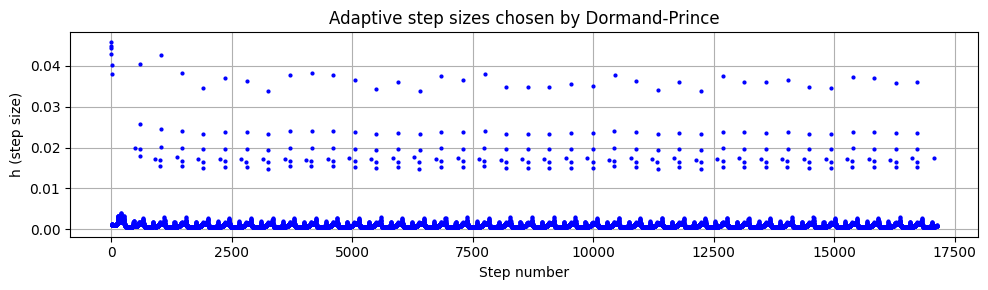

Min step size: 4.524326e-04
Max step size: 4.592982e-02


In [8]:
# Visualize the adaptive step sizes chosen by Dormand-Prince
xs_dp_flat = xs_dp.flatten()
h_values = np.diff(xs_dp_flat)

plt.figure(figsize=(10, 3))
plt.plot(h_values, 'bo', markersize=2)
plt.xlabel('Step number')
plt.ylabel('h (step size)')
plt.title('Adaptive step sizes chosen by Dormand-Prince')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Min step size: {np.min(h_values):.6e}")
print(f"Max step size: {np.max(h_values):.6e}")

## Part (c) — Phase Space Trajectory ($y'$ vs $y$)

The  phase space trajectory plots $y'(t)$ against $y(t)$. For $\mu = 5$, the Van der Pol oscillator exhibits a **limit cycle** — the trajectory spirals outward from any initial condition inside the cycle and inward from outside, converging to a stable closed orbit.

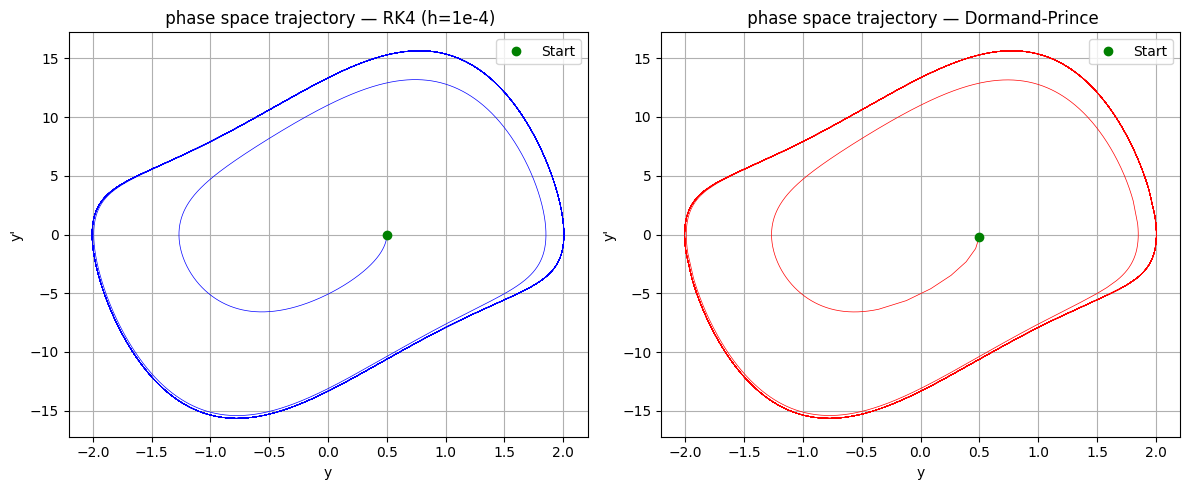

In [10]:
# Part (c): Phase space plot (y' vs y)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# RK4 phase portrait
axes[0].plot(ys_rk4[:, 0], ys_rk4[:, 1], 'b-', linewidth=0.5)
axes[0].plot(ys_rk4[0, 0], ys_rk4[0, 1], 'go', markersize=6, label='Start')
axes[0].set_xlabel('y')
axes[0].set_ylabel("y'")
axes[0].set_title(' phase space trajectory — RK4 (h=1e-4)')
axes[0].legend()
axes[0].grid(True)

# Dormand-Prince phase portrait
axes[1].plot(ys_dp[:, 0], ys_dp[:, 1], 'r-', linewidth=0.5)
axes[1].plot(ys_dp[0, 0], ys_dp[0, 1], 'go', markersize=6, label='Start')
axes[1].set_xlabel('y')
axes[1].set_ylabel("y'")
axes[1].set_title(' phase space trajectory — Dormand-Prince')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()